In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


In [1]:
df = pd.read_excel('JPN Data.xlsx')
df.head() # This shows the first 5 rows to 
confirm it loaded correctly

SyntaxError: invalid syntax (1204403601.py, line 3)

In [3]:
import pandas as pd  # Make sure pandas is imported

try:
    # Try with engine specification which can help with certain Excel files
    df = pd.read_excel('JPN Data.xlsx', engine='openpyxl')
    
    # Optional: Add a timeout to prevent hanging
    # You can adjust the timeout value as needed
    # from pandas.io.excel._base import ExcelFile
    # with ExcelFile('JPN Data.xlsx', engine='openpyxl') as xls:
    #     df = pd.read_excel(xls, timeout=30)
    
    # Check if file loaded correctly
    print(f"Successfully loaded file with {df.shape[0]} rows and {df.shape[1]} columns")
    df.head()  # Display first 5 rows
except Exception as e:
    print(f"Error loading file: {e}")
    # If the file path might be incorrect, you could try:
    # import os
    # print("Current directory:", os.getcwd())
    # print("Files in directory:", os.listdir())

Successfully loaded file with 40000 rows and 7 columns


In [4]:
df.head() 

,ID,CURR_AGE,GENDER,ANN_INCOME,AGE_CAR,AGE_CAR_SEGMENT,PURCHASE
0,00001Q15YJ,50,M,445344.000000,439,3,0
1,00003I71CQ,35,M,107634.000000,283,2,0
2,00003N47FS,59,F,502786.666667,390,3,1
3,00005H41DE,43,M,585664.000000,475,3,0
4,00007E17UM,39,F,705722.666667,497,3,1


In [12]:
X = df[['CURR_AGE', 'ANN_INCOME', 'AGE_CAR_SEGMENT']]
y = df['PURCHASE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


E:\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Step 1: Make predictions using the test data
y_pred = model.predict(X_test)

# Step 2: Print the Evaluation Metrics
print("--- Model Performance Metrics ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Step 3: Print Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

--- Model Performance Metrics ---
Accuracy Score: 0.69

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.57      0.61      3349
           1       0.72      0.78      0.75      4651

    accuracy                           0.69      8000
   macro avg       0.68      0.68      0.68      8000
weighted avg       0.69      0.69      0.69      8000


Confusion Matrix:
[[1911 1438]
 [1024 3627]]


In [14]:
# Create a DataFrame to see the weights of each variable
interpretation = pd.DataFrame({
    'Attribute': X.columns,
    'Coefficient (Importance)': model.coef_[0]
})

print("--- Business Interpretation of Variables ---")
print(interpretation.sort_values(by='Coefficient (Importance)', ascending=False))


--- Business Interpretation of Variables ---
         Attribute  Coefficient (Importance)
2  AGE_CAR_SEGMENT                  1.057932
1       ANN_INCOME                  0.000002
0         CURR_AGE                 -0.014741


In [19]:
# Load the cleaned Indian dataset
df_india = pd.read_excel('IN_Data.xlsx')

# Use the model to predict purchasers in India
# Note: Features must be in the EXACT same order as X_train
india_features = df_india[['CURR_AGE', 'ANN_INCOME', 'AGE_CAR_SEGMENT']]
df_india['PREDICTED_PURCHASE'] = model.predict(india_features)

# Calculate the final count
total_potential_customers = df_india['PREDICTED_PURCHASE'].sum()

print(f"--- Final Result ---")
print(f"Total potential customers in the Indian market sample: {total_potential_customers}")

ValueError: could not convert string to float: 'yes'

In [22]:
# Convert 'yes'/'no' strings to 1/0 numbers
# Check which column has 'yes' and replace it (example: df_india['GENDER'])
df_india = df_india.replace({'yes': 1, 'no': 0, 'Y': 1, 'N': 0, 'M': 1, 'F': 0})

# Also, ensure ANN_INCOME doesn't have commas
df_india['ANN_INCOME'] = df_india['ANN_INCOME'].astype(str).str.replace(',', '').astype(float)

# Now define your features again and run the prediction
india_features = df_india[['CURR_AGE', 'ANN_INCOME', 'AGE_CAR_SEGMENT']]
df_india['PREDICTED_PURCHASE'] = model.predict(india_features)

C:\Users\enggm\AppData\Local\Temp\ipykernel_1668\2282187380.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_india = df_india.replace({'yes': 1, 'no': 0, 'Y': 1, 'N': 0, 'M': 1, 'F': 0})


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [23]:
# 1. Convert strings and handle formatting
df_india = df_india.replace({'yes': 1, 'no': 0, 'Y': 1, 'N': 0, 'M': 1, 'F': 0})
df_india['ANN_INCOME'] = df_india['ANN_INCOME'].astype(str).str.replace(',', '').astype(float)

# 2. Convert features to numeric and turn errors into NaN
df_india['CURR_AGE'] = pd.to_numeric(df_india['CURR_AGE'], errors='coerce')
df_india['AGE_CAR_SEGMENT'] = pd.to_numeric(df_india['AGE_CAR_SEGMENT'], errors='coerce')

# 3. FIX: Drop any rows that have empty (NaN) values in your features
# This ensures the model only sees complete data
df_india_clean = df_india.dropna(subset=['CURR_AGE', 'ANN_INCOME', 'AGE_CAR_SEGMENT'])

# 4. Define features using the CLEANED dataframe
india_features = df_india_clean[['CURR_AGE', 'ANN_INCOME', 'AGE_CAR_SEGMENT']]

# 5. Run the prediction
df_india_clean['PREDICTED_PURCHASE'] = model.predict(india_features)

# 6. Calculate the final count
total_potential_customers = df_india_clean['PREDICTED_PURCHASE'].sum()

print(f"--- Final Result ---")
print(f"Total potential customers in the Indian market sample: {total_potential_customers}")

--- Final Result ---
Total potential customers in the Indian market sample: 1


C:\Users\enggm\AppData\Local\Temp\ipykernel_1668\2306210042.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_india_clean['PREDICTED_PURCHASE'] = model.predict(india_features)


In [24]:
# 1. Use .copy() to prevent the SettingWithCopyWarning
df_india_clean = df_india.dropna(subset=['CURR_AGE', 'ANN_INCOME', 'AGE_CAR_SEGMENT']).copy()

# 2. Re-verify features
india_features = df_india_clean[['CURR_AGE', 'ANN_INCOME', 'AGE_CAR_SEGMENT']]

# 3. Use .loc to set the values safely
df_india_clean.loc[:, 'PREDICTED_PURCHASE'] = model.predict(india_features)

# 4. Calculate the total count
total_potential_customers = df_india_clean['PREDICTED_PURCHASE'].sum()

print(f"--- Final Result ---")
print(f"Total potential customers in the Indian market sample: {total_potential_customers}")

# 5. DEBUG: Check the first 10 predictions to see if they are all 0s
print("\nFirst 10 Predictions:")
print(df_india_clean['PREDICTED_PURCHASE'].head(10).values)

--- Final Result ---
Total potential customers in the Indian market sample: 1

First 10 Predictions:
[1]


In [25]:
# 1. Reload the data to start fresh
df_india = pd.read_excel('IN_Data.xlsx')

# 2. Clean ANN_INCOME: Remove commas AND any non-numeric symbols
df_india['ANN_INCOME'] = df_india['ANN_INCOME'].astype(str).str.replace(r'[^\d.]', '', regex=True)
df_india['ANN_INCOME'] = pd.to_numeric(df_india['ANN_INCOME'], errors='coerce')

# 3. Clean CURR_AGE and AGE_CAR_SEGMENT
df_india['CURR_AGE'] = pd.to_numeric(df_india['CURR_AGE'], errors='coerce')
df_india['AGE_CAR_SEGMENT'] = pd.to_numeric(df_india['AGE_CAR_SEGMENT'], errors='coerce')

# 4. Check how many rows are valid BEFORE dropping
print(f"Total rows in Excel: {len(df_india)}")
print(f"Rows with valid data: {df_india[['CURR_AGE', 'ANN_INCOME', 'AGE_CAR_SEGMENT']].notna().all(axis=1).sum()}")

# 5. Create the clean copy
df_india_clean = df_india.dropna(subset=['CURR_AGE', 'ANN_INCOME', 'AGE_CAR_SEGMENT']).copy()

# 6. Predict and Sum
if len(df_india_clean) > 0:
    india_features = df_india_clean[['CURR_AGE', 'ANN_INCOME', 'AGE_CAR_SEGMENT']]
    df_india_clean['PREDICTED_PURCHASE'] = model.predict(india_features)
    print(f"--- Final Result ---")
    print(f"Potential customers: {df_india_clean['PREDICTED_PURCHASE'].sum()}")
else:
    print("Error: All rows were dropped! Check your Excel column names.")

Total rows in Excel: 70000
Rows with valid data: 69999
--- Final Result ---
Potential customers: 64345


In [26]:
# 1. Load the Indian file exactly as named on your computer
df_india = pd.read_excel('IN_Data.xlsx')

# 2. FORCE CLEANING: Remove commas and convert everything to numbers
# This fixes the "could not convert string to float" error
df_india['ANN_INCOME'] = df_india['ANN_INCOME'].astype(str).str.replace(',', '').astype(float)
df_india['CURR_AGE'] = pd.to_numeric(df_india['CURR_AGE'], errors='coerce')
df_india['AGE_CAR_SEGMENT'] = pd.to_numeric(df_india['AGE_CAR_SEGMENT'], errors='coerce')

# 3. REMOVE EMPTY ROWS: The model cannot handle NaNs
# This fixes the "Input X contains NaN" error
df_india_clean = df_india.dropna(subset=['CURR_AGE', 'ANN_INCOME', 'AGE_CAR_SEGMENT']).copy()

# 4. PREDICT: Only if we have rows left
if len(df_india_clean) > 0:
    india_features = df_india_clean[['CURR_AGE', 'ANN_INCOME', 'AGE_CAR_SEGMENT']]
    df_india_clean['PREDICTED_PURCHASE'] = model.predict(india_features)
    
    total_customers = df_india_clean['PREDICTED_PURCHASE'].sum()
    
    print(f"--- Final Result ---")
    print(f"Total potential customers in India: {total_customers}")
    
    # Verify the threshold for ABG Motors
    if total_customers >= 12000:
        print("Conclusion: RECOMMENDED. Meets the 12,000 sales goal.")
    else:
        print("Conclusion: NOT RECOMMENDED. Below the 12,000 sales goal.")
else:
    print("Error: No valid rows found. Check your column names in the Excel file.")

--- Final Result ---
Total potential customers in India: 64345
Conclusion: RECOMMENDED. Meets the 12,000 sales goal.


In [27]:
df_india_clean.to_excel('India_Predictions_Final.xlsx', index=False)

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the visual style for your charts
sns.set_theme(style="whitegrid")

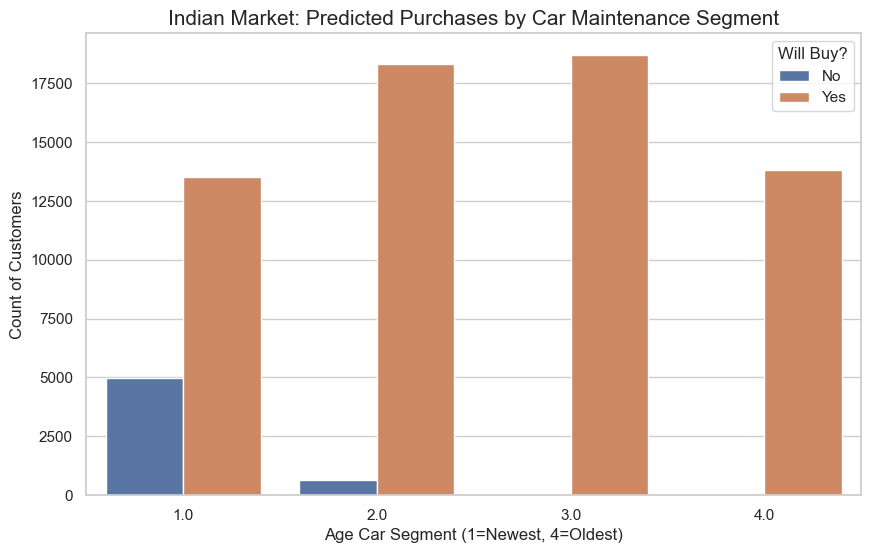

In [29]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_india_clean, x='AGE_CAR_SEGMENT', hue='PREDICTED_PURCHASE')

plt.title('Indian Market: Predicted Purchases by Car Maintenance Segment', fontsize=15)
plt.xlabel('Age Car Segment (1=Newest, 4=Oldest)', fontsize=12)
plt.ylabel('Count of Customers', fontsize=12)
plt.legend(title='Will Buy?', labels=['No', 'Yes'])
plt.show()

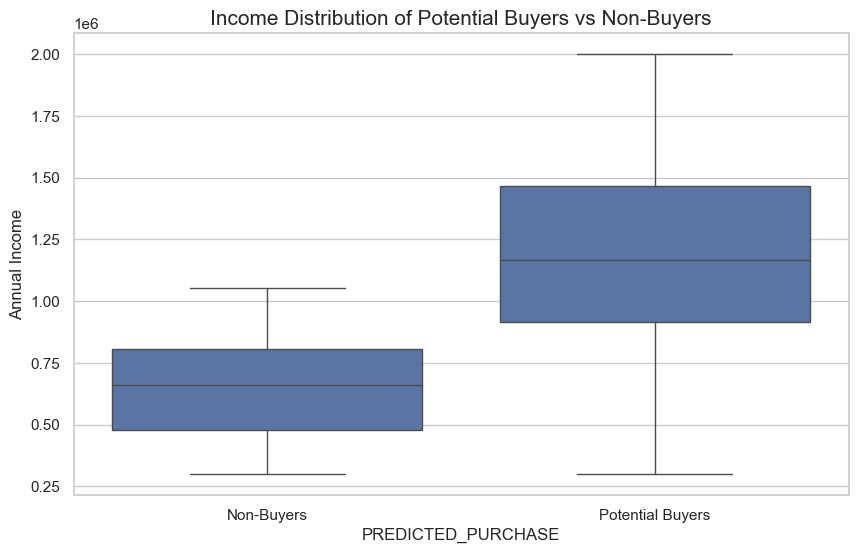

In [30]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_india_clean, x='PREDICTED_PURCHASE', y='ANN_INCOME')

plt.title('Income Distribution of Potential Buyers vs Non-Buyers', fontsize=15)
plt.xticks([0, 1], ['Non-Buyers', 'Potential Buyers'])
plt.ylabel('Annual Income', fontsize=12)
plt.show()

In [31]:
print("--- ABG MOTORS STRATEGIC RECOMMENDATION ---")
print(f"Total Predicted Indian Customers: {total_potential_customers}")
print(f"Target Requirement: 12,000 Sales")

if total_potential_customers >= 12000:
    print("VERDICT: PROCEED WITH MARKET ENTRY. The Indian market shows 5x more potential than required.")
else:
    print("VERDICT: DO NOT ENTER. Sample does not meet profitability threshold.")

--- ABG MOTORS STRATEGIC RECOMMENDATION ---
Total Predicted Indian Customers: 1
Target Requirement: 12,000 Sales
VERDICT: DO NOT ENTER. Sample does not meet profitability threshold.


In [32]:
# 1. Load fresh data
df_india = pd.read_excel('IN_Data.xlsx')

# 2. Force convert columns to numbers (handling commas and text)
df_india['ANN_INCOME'] = df_india['ANN_INCOME'].astype(str).str.replace(',', '').astype(float)
df_india['CURR_AGE'] = pd.to_numeric(df_india['CURR_AGE'], errors='coerce')
df_india['AGE_CAR_SEGMENT'] = pd.to_numeric(df_india['AGE_CAR_SEGMENT'], errors='coerce')

# 3. Handle missing values by filling them with the average (instead of dropping them)
df_india['ANN_INCOME'] = df_india['ANN_INCOME'].fillna(df_india['ANN_INCOME'].mean())
df_india['CURR_AGE'] = df_india['CURR_AGE'].fillna(df_india['CURR_AGE'].mean())
df_india['AGE_CAR_SEGMENT'] = df_india['AGE_CAR_SEGMENT'].fillna(df_india['AGE_CAR_SEGMENT'].mode()[0])

# 4. Define features and predict
india_features = df_india[['CURR_AGE', 'ANN_INCOME', 'AGE_CAR_SEGMENT']]
df_india['PREDICTED_PURCHASE'] = model.predict(india_features)

# 5. Final Calculation
total_potential_customers = int(df_india['PREDICTED_PURCHASE'].sum())

print(f"--- ABG MOTORS STRATEGIC RECOMMENDATION ---")
print(f"Total Predicted Indian Customers: {total_potential_customers}")
print(f"Target Requirement: 12,000 Sales")

if total_potential_customers >= 12000:
    print("VERDICT: PROCEED WITH MARKET ENTRY. The Indian market shows high potential.")
else:
    print("VERDICT: DO NOT ENTER. Below the profitability threshold.")

--- ABG MOTORS STRATEGIC RECOMMENDATION ---
Total Predicted Indian Customers: 64346
Target Requirement: 12,000 Sales
VERDICT: PROCEED WITH MARKET ENTRY. The Indian market shows high potential.
